# Does the Canonical HMM Fit My Data?

The canonical HMMs were trained on [Cam-CAN](https://cam-can.mrc-cbu.cam.ac.uk/dataset/) data. When we apply one to a new dataset, recorded on a different scanner, with a different modality, or with a different preprocessing pipeline, we would like to know whether the model is a reasonable description of the new data.

This tutorial shows how to answer that question using the **variational free energy**.

#### What is the free energy?

The variational free energy is the quantity we minimise when we train an HMM. It is an upper bound on the negative log-evidence, $-\log p(x)$. **Lower is better.**

On its own a free energy value is not interpretable: it has arbitrary units and depends on the number of channels, the number of states and the parcellation. It only becomes meaningful when we compare it with other values calculated with **the same model**.

This is what the `fe.npy` files in the `/models` directory are for. Each one contains the free energy of every Cam-CAN session, evaluated with the canonical HMM for that parcellation and number of states. This gives us a reference distribution: if a new session has a free energy that sits inside the Cam-CAN distribution, the canonical HMM describes it about as well as it describes the data it was trained on.

Note the free energies are **normalised by the number of time points**, so sessions of different lengths can be compared.

#### Requirements

We will use the parcellated data produced by the other tutorials, i.e. the `lcmv-parc-raw.fif` files in `BIDS/derivatives/osl`. You need to have run at least one of `elekta_meg_parcel.ipynb`, `ctf_meg.ipynb`, `opm.ipynb` or `eeg.ipynb` first.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from modules import hmm

from osl_dynamics.data import Data

## 1. Calculate the Free Energy of a New Session

We need to prepare the data in exactly the same way as we would to fit the canonical HMM. The free energy depends on the preparation, so if you use a different set of steps here, the value will not be comparable with the Cam-CAN distribution.

In [9]:
id = "sub-01_task-resteyesclosed"
parcellation = "Glasser52"
n_states = 8

# Load and prepare the parcellated data
parc_fif = f"BIDS/derivatives/osl/{id}/lcmv-parc-raw.fif"
data = Data(parc_fif, picks="misc", reject_by_annotation="omit")
data = hmm.prepare_data_for_canonical_hmm(data, parcellation=parcellation)

Loading files:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating covariances:   0%|          | 0/1 [00:00<?, ?it/s]

Sign flipping:   0%|          | 0/1 [00:00<?, ?it/s]

2026-07-28 09:08:56 INFO osl-dynamics [base.py:1187:align_channel_signs]: Mean correlation with template: 0.096 (min: 0.096)


TDE-PCA:   0%|          | 0/1 [00:00<?, ?it/s]

Standardize:   0%|          | 0/1 [00:00<?, ?it/s]

Now we load the canonical HMM and evaluate the free energy. Note, we do not train the model here, we only run inference (the forward-backward algorithm) to get the state probabilities the free energy is calculated from.

In [10]:
model = hmm.load_canonical_hmm(n_states=n_states, parcellation=parcellation)

fe = model.free_energy(data)
print(f"Free energy: {fe:.2f}")

Getting free energy:   0%|          | 0/1 [00:00<?, ?it/s]

2026-07-28 09:09:02 WARNING tensorflow [polymorphic_function.py:157:called_with_tracing]: 6 out of the last 16 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x150385da0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


Free energy: 169.28


2026-07-28 09:09:02.203360: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 2. Compare With the Cam-CAN Distribution

Let's load the free energy of each Cam-CAN session for this model.

In [11]:
reference_fe = hmm.load_canonical_free_energy(n_states=n_states, parcellation=parcellation)
print(reference_fe.shape)
print(f"Cam-CAN free energy: {reference_fe.mean():.2f} +/- {reference_fe.std():.2f} "
      f"(range: {reference_fe.min():.2f} to {reference_fe.max():.2f})")

(1849,)
Cam-CAN free energy: 166.19 +/- 2.14 (range: 155.92 to 173.61)


And plot our session on top of the distribution.

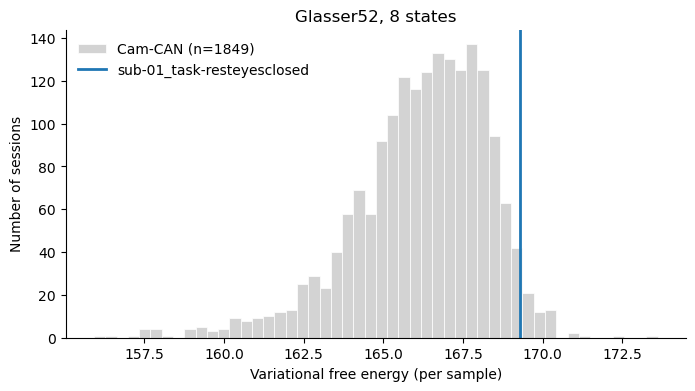

In [12]:
fig, ax = hmm.plot_free_energy_distribution(
    fe,
    n_states=n_states,
    parcellation=parcellation,
    labels=id,
)

A convenient summary is the percentile: the percentage of Cam-CAN sessions with a **lower** (i.e. better) free energy than ours.

In [13]:
percentile = hmm.free_energy_percentile(fe, n_states=n_states, parcellation=parcellation)
print(f"{id}: {percentile[0]:.1f}th percentile")

sub-01_task-resteyesclosed: 97.0th percentile


#### Note: loading multiple files together

You can pass a list of files to `Data` and prepare them all in one go, which is faster for large datasets:

```python
parc_fifs = [f"BIDS/derivatives/osl/{id}/lcmv-parc-raw.fif" for id in ids]
data = Data(parc_fifs, picks="misc", reject_by_annotation="omit", n_jobs=4)
data = hmm.prepare_data_for_canonical_hmm(data, parcellation=parcellation)

model = hmm.load_canonical_hmm(n_states=n_states, parcellation=parcellation)

# free_energy returns a single value for whatever it is passed, so we ask for
# one dataset per session to get a value for each session
datasets = model.make_dataset(data, concatenate=False)
fe = [model.free_energy(dataset) for dataset in datasets]
```

## 3. How to Interpret the Result

**Inside the distribution.** The canonical HMM describes your data about as well as it describes the data it was trained on. You can be confident using it.

**Towards the upper end, but still inside.** This is the typical result for non-Cam-CAN data and is not a cause for concern. It is worth sanity checking your preprocessing, but the model is still applicable.

**Outside the distribution (above the maximum).** The canonical HMM might be a poor description of your data. The most common causes are a mismatch with the training data:

- The sampling frequency is not 250 Hz.
- A different parcellation was used, or the parcels are ordered differently.
- The data was not source reconstructed and parcellated in a comparable way (e.g. no spatial leakage correction).
- The frequency range is very different from the training data (0.5-45 Hz).
- The data is very noisy, or contains large artefacts that were not removed.

If none of these apply, it may simply be that your data is genuinely different from Cam-CAN data, in which case you may want to train an HMM on your own data instead. See the [osl-dynamics documentation](https://osl-dynamics.readthedocs.io/en/latest/documentation.html) for how to do this.